# 📄 Resume Analyzer — NLP Preprocessing Pipeline

## 🎯 Objective
The objective of this notebook is to preprocess raw resume data using Natural Language Processing (NLP) techniques. This step prepares the textual data so that it can be used effectively for machine learning models in the next phase.

---

## Pipeline Overview

This notebook performs the following steps:

1. Initialization and Library Import
2. Data Loading
3. Data Inspection
4. Text Cleaning
5. Tokenization
6. Lemmatization
7. Save Cleaned Data

---

## Dataset Description

The dataset contains the following columns:

- **ID** → Unique identifier for each resume (not used in ML)
- **Resume_str** → Raw resume text (primary input feature)
- **Resume_html** → HTML version of resume (optional, not used here)
- **Category** → Job category (target variable)

In [ ]:
# ================================
# LIBRARY IMPORTS
# ================================

import pandas as pd
import numpy as np

# NLP Libraries
import re
import string

# NLTK for NLP processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Visualization (for later use)
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

# ================================
#  DOWNLOADING NLTK RESOURCES
# ================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# ================================
# INITIALIZING NLP COMPONENTS
# ================================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("NLP tools initialized successfully !")

## Step 1: Data Loading and Initial Inspection

In this step, we are:
- Load the dataset from a CSV file into a pandas DataFrame
- Standardize column names
- Preview the dataset
- Examine its shape, columns, and data types

In [5]:
# Load dataset
df = pd.read_csv("Resume.csv")

# Clean column names (remove extra spaces if any)
df.columns = df.columns.str.strip()

# Preview first 5 rows
print("First 5 rows of dataset:")
display(df.head())


# ================================
# Basic Dataset Information
# ================================

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

First 5 rows of dataset:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. ...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME500375979"" style=""\n padding-top:0px;\n ""> <div class...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communications, Marketing, Human Resources and Technology. Experience 09/201...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME911808366"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources Executive Management, 5 years of HRIS development and maintenance 4 years work...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME1008511259"" style=""padding-top:0px;""> <div class=""paragraph P...",HR
3,27018550,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expertise. Motivated to maintain customer satisfaction and contribute to company succe...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME992636658"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Startups Employment Law FMLA/ADA/EEO/WC Mediation & Advocacy HR Policies & Proce...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME666809417"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR



Dataset Shape (Rows, Columns):
(2484, 4)

Column Names:
['ID', 'Resume_str', 'Resume_html', 'Category']

Data Types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


## Step 2: Missing Values and Data Quality Analysis

In this step, we are:
- Check for missing values in each column
- Calculate the percentage of missing data
- Identify duplicate records
- Ensure data integrity before preprocessing

In [6]:
print("Missing Values in Each Column:\n")

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

display(missing_df)


# ================================
# Duplicate Records Check
# ================================

duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)

Missing Values in Each Column:



,Missing Values,Percentage (%)
ID,0,0.0
Resume_str,0,0.0
Resume_html,0,0.0
Category,0,0.0



Number of Duplicate Rows: 0


## Step 3: Category Distribution Analysis

In this step, we:
- Count the number of resumes in each category
- Analyze the distribution of classes
- Visualize the distribution using a bar plot

Category Distribution:



Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

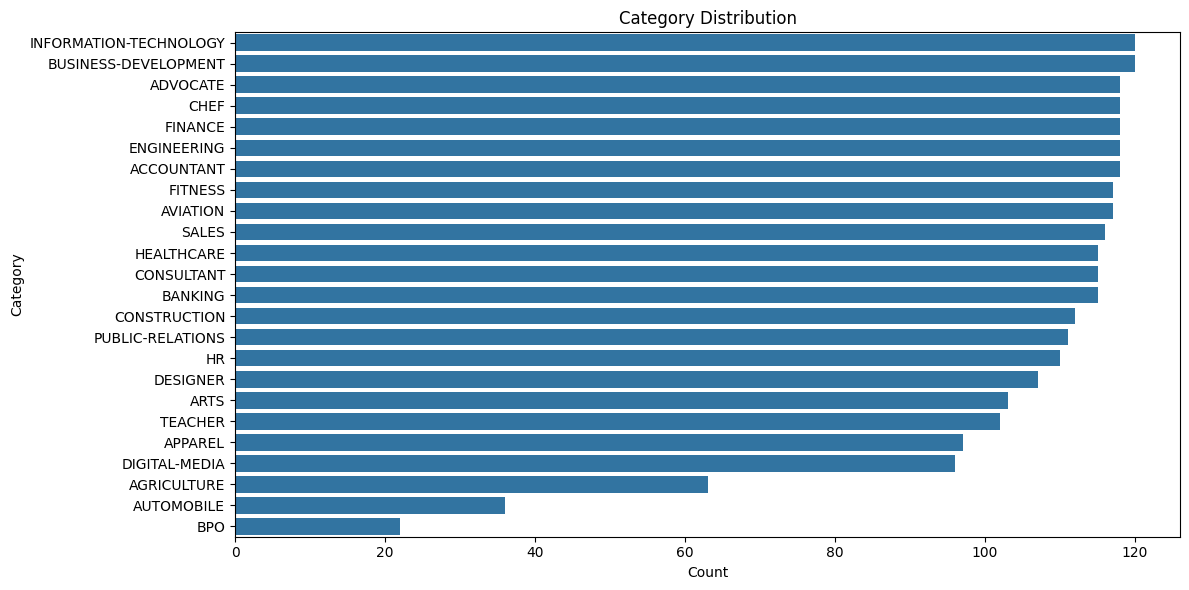

In [7]:
# Count values
category_counts = df['Category'].value_counts()

print("Category Distribution:\n")
display(category_counts)


# ================================
# Visualization
# ================================

plt.figure(figsize=(12, 6))
sns.countplot(y=df['Category'], order=category_counts.index)

plt.title("Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Step 4: Resume Length Analysis

In this step, we:
- Compute the length of each resume
- Generate descriptive statistics
- Visualize the distribution of resume lengths

This helps identify:
- Extremely short resumes (potential noise)
- Extremely long resumes (potential outliers)
- Overall text variability

Understanding text length is important before applying NLP techniques, as it can influence feature extraction and model performance.

In [ ]:
# ================================
# Step 4: Resume Length Analysis
# ================================

# Create a new column for resume length
df['Resume_Length'] = df['Resume_str'].astype(str).apply(len)

print("Resume Length Statistics:\n")
display(df['Resume_Length'].describe())


# ================================
# Visualization
# ================================

plt.figure(figsize=(10, 5))
plt.hist(df['Resume_Length'], bins=50)

plt.title("Resume Length Distribution")
plt.xlabel("Length (Number of Characters)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()